Reanalysis of Timm (1975) / Friendly (2007) using `bootridge` from the
statistics-resampling package. Five paired-associate (PA) task scores predict
three aptitude outcomes (SAT, PPVT, Raven) in 69 kindergarten children
split by socioeconomic status (Lo SES n=37, Hi SES n=32).

Primary comparison: unpenalised OLS (matching published analyses) vs
empirical Bayes ridge regression with bootstrap-calibrated inference.

In [4]:
pkg load statistics-resampling 
pkg load statistics-resampling 
graphics_toolkit ("gnuplot")


The gnuplot graphics toolkit is not actively maintained and has a number
of limitations that are unlikely to be fixed.  Communication with gnuplot
uses a one-directional pipe and limited information is passed back to the
Octave interpreter so most changes made interactively in the plot window
will not be reflected in the graphics properties managed by Octave.  For
example, if the plot window is closed with a mouse click, Octave will not
be notified and will not update its internal list of open figure windows.
The qt toolkit is recommended instead.


In [5]:
fid = fopen ('../data/rohwer_data.csv');
C = textscan (fid, '%d %q %f %f %f %f %f %f %f %f', ...
              'Delimiter', ',', 'HeaderLines', 1);
fclose (fid);

group = C{1};  SES  = C{2};
SAT   = C{3};  PPVT = C{4};  Raven = C{5};
n_pa  = C{6};  s_pa = C{7};  ns_pa = C{8};
na_pa = C{9};  ss_pa = C{10};

Y = [SAT, PPVT, Raven];

lo_idx = strcmp (SES, 'Lo');
hi_idx = strcmp (SES, 'Hi');

fprintf ('Lo SES: %d children\n', sum (lo_idx))
fprintf ('Hi SES: %d children\n', sum (hi_idx))

Lo SES: 37 children
Hi SES: 32 children



| Variable | Description | Role |
|---|---|---|
| SAT | School aptitude test score | Outcome |
| PPVT | Peabody Picture Vocabulary Test | Outcome |
| Raven | Raven Progressive Matrices | Outcome |
| n | Named PA task score | Predictor |
| s | Still PA task score | Predictor |
| ns | Named-still PA task score | Predictor |
| na | Named-action PA task score | Predictor |
| ss | Sentence-still PA task score | Predictor |

Predictors correlate up to r = 0.80 (na and ss) — the multicollinearity
problem that ridge regression is designed to address.

In [6]:
Y_lo  = Y(lo_idx, :);
n_lo  = n_pa(lo_idx);   s_lo  = s_pa(lo_idx);
ns_lo = ns_pa(lo_idx);  na_lo = na_pa(lo_idx);
ss_lo = ss_pa(lo_idx);

fprintf ('Predictor correlation matrix (Lo SES):\n')
disp (corr ([n_lo, s_lo, ns_lo, na_lo, ss_lo]))

Predictor correlation matrix (Lo SES):
   1.0000   0.4007   0.5370   0.6481   0.6704
   0.4007   1.0000   0.3523   0.6478   0.4252
   0.5370   0.3523   1.0000   0.7136   0.7695
   0.6481   0.6478   0.7136   1.0000   0.7951
   0.6704   0.4252   0.7695   0.7951   1.0000


                                                                               
           |   Normal Q-Q Plot                |Spread-Location Plot            
        4 $|+$$$$$$$$$$$$$$$$$$$$$$$       2 %|%%%%%%%%%%%%%%%%%%%%%%%%        
          $|  $   $    $   $   $ ###         $|$$$$$$$$$$$$$$$$$$$$$$$$        
        2 $|+$$$$$$$$$$$$$$$$#  9 30     1.5 #|################  22 30#        
          $|##$###$####$F####F#$## $         #|######F###  9##F######F         
        0 $|+$$$$$$$$#sqrt ( | Studentized Res|dua  3| )#F##F#FFFFF##          
          $|##$FF#  3FF$###$###$## $         #|#####FF##FF#F#F#FF##FF          
       -2 $|+  22$$$$$$$$$$$$$$$$$$$     0.5 +|F#####FF##########F###          
          #|-------------------------        +|-------------------------       
       -4 +-+$+$$$+$$$$+$$$+$$$+$$$+       0 +-+###+######+#####+#### +        
         -3  -2  -1    0   1   2   3        40    50     60    70    80        
           Residual-Leverage Plot       

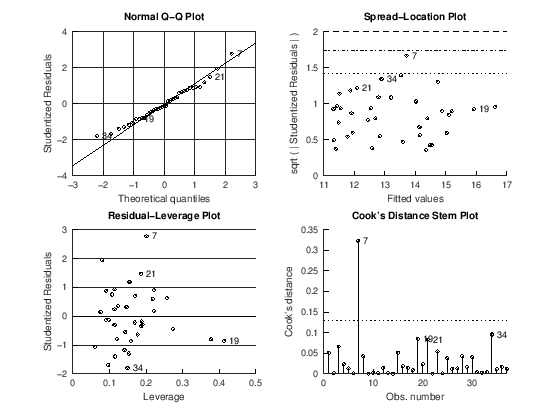

In [7]:
outcome_names = {'SAT', 'PPVT', 'Raven'};

for i = 1:3
  MAT_diag = bootlm (Y_lo(:,i), {n_lo, s_lo, ns_lo, na_lo, ss_lo}, ...
                     'continuous', [1:5], 'model', 'linear', 'display', 'on', ...
                     'nboot', 0, 'varnames', {'n','s','ns','na','ss'});
  print (sprintf ('../output/Rohwer_Lo_%s_diagnostic.png', outcome_names{i}), ...
         '-dpng', '-r300')
end

In [19]:
fprintf ('=== UNPENALISED OLS: Lo SES (matching Timm 1975) ===\n\n')
fprintf ('%-8s  %10s  %10s  %10s\n', 'Predictor', 'SAT p', 'PPVT p', 'Raven p')
fprintf ('%s\n', repmat ('-', 1, 42))

ols_p = zeros (6, 3);  
ols_b = zeros (6, 3);

for i = 1:3
  [STATS_ols] = bootlm (Y_lo(:,i), {n_lo, s_lo, ns_lo, na_lo, ss_lo}, ...
                         'continuous', [1:5], 'model', 'linear', 'display', 'off', ...
                         'method', 'wild', 'nboot', 999, 'seed', 1, ...
                         'varnames', {'n','s','ns','na','ss'});
  fieldnames(STATS_ols)          % <-- add it HERE, right after bootlm creates it
  ols_p(:,i) = STATS_ols.pval;
  ols_b(:,i) = STATS_ols.estimate;
end

pred_labels = {'intercept','n','s','ns','na','ss'};
for r = 1:6
  flags = cell (1, 3);
  for j = 1:3
    p = ols_p(r,j);
    if    p < 0.001; flags{j} = '***';
    elseif p < 0.01; flags{j} = '**';
    elseif p < 0.05; flags{j} = '*';
    else;            flags{j} = '';
    end
  end
  fprintf ('%-8s  %8.4f %-3s  %8.4f %-3s  %8.4f %-3s\n', pred_labels{r}, ...
           ols_p(r,1), flags{1}, ols_p(r,2), flags{2}, ols_p(r,3), flags{3});
end

=== UNPENALISED OLS: Lo SES (matching Timm 1975) ===

Predictor       SAT p      PPVT p     Raven p
------------------------------------------
ans =
{
  [1,1] = method
  [2,1] = name
  [3,1] = estimate
  [4,1] = CI_lower
  [5,1] = CI_upper
  [6,1] = pval
  [7,1] = fpr
  [8,1] = N
  [9,1] = prior
  [10,1] = levels
  [11,1] = contrasts
}

ans =
{
  [1,1] = method
  [2,1] = name
  [3,1] = estimate
  [4,1] = CI_lower
  [5,1] = CI_upper
  [6,1] = pval
  [7,1] = fpr
  [8,1] = N
  [9,1] = prior
  [10,1] = levels
  [11,1] = contrasts
}

ans =
{
  [1,1] = method
  [2,1] = name
  [3,1] = estimate
  [4,1] = CI_lower
  [5,1] = CI_upper
  [6,1] = pval
  [7,1] = fpr
  [8,1] = N
  [9,1] = prior
  [10,1] = levels
  [11,1] = contrasts
}

intercept    0.6952        0.0010 **     0.0010 ** 
n           0.7017        0.9097        0.3028    
s           0.9472        0.0521        0.6517    
ns          0.0205 *      0.4651        0.1266    
na          0.5982        0.0010 **     0.7998    
ss          0

In [20]:
MAT_lo = bootlm (Y_lo(:,1), {n_lo, s_lo, ns_lo, na_lo, ss_lo}, ...
                 'continuous', [1:5], 'model', 'linear', 'display', 'off', ...
                 'nboot', 0, 'varnames', {'n','s','ns','na','ss'});

size (MAT_lo.X)

ans =

   37    6



Running bootridge: Lo SES, main effects, 3 outcomes jointly...

 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 3

 Sample size: 37

 Design effect (Deff): 1

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 2.55991

 Predicted R-squared: 0.147 (14.7%)

 Bootstrap optimized ridge tuning constant (lambda): 18.4192

 Effective residual degrees of freedom (df_lambda): 33.5

 Residual variances (range): [8.26, 454]

 Inferential degrees of freedom (df_t): 33.5
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             +0.2680       -0.08715      +0.5627  
 1             3             +0.1798       -0.1783       +

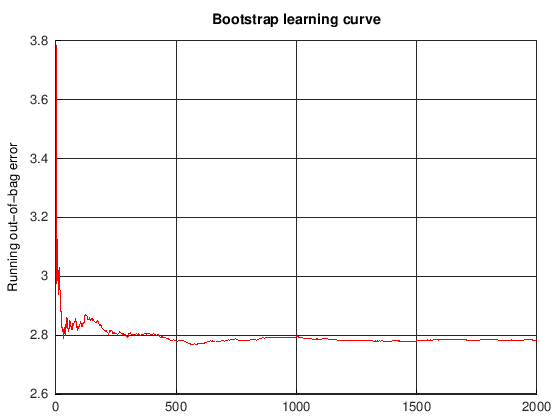

In [10]:
# ridge regression — all 3 outcomes simultaneously
# [] for CATEGOR = all predictors continuous
# Deff = 1 here (independent children, no clustering)

fprintf ('Running bootridge: Lo SES, main effects, 3 outcomes jointly...\n')

tic
bootridge (Y_lo, MAT_lo.X, [], 1999, 0.05);
toc
ridge_lo = ans;

In [11]:
disp (ridge_lo.stability * 100)


      NaN      NaN      NaN
   61.175   86.125   91.275
   59.425   65.275   72.225
   90.475   75.225   96.525
   86.025   99.975   69.875
   99.725   98.425   67.875


In [12]:
ridge_lo.BF10


ans =

      NaN      NaN      NaN
   0.6854   0.8104   0.9182
   0.6596   0.6822   0.6995
   0.9695   0.7854   1.6690
   0.9032   8.1757   0.7885
   1.7081   1.6944   0.7726



In [13]:
fprintf ('=== COMPARISON: OLS p-values vs Ridge BF10 and Stability Selection ===\n')
fprintf ('Lo SES subset — main effects model — 3 outcomes\n\n')

for o = 1:3
  fprintf ('--- %s ---\n', outcome_names{o})
  fprintf ('%-10s  %10s  %10s  %8s\n', 'Predictor', 'OLS p', 'BF10', 'SS%')
  fprintf ('%s\n', repmat ('-', 1, 44))
  for r = 2:6   # skip intercept row
    p_val  = ols_p(r, o);
    bf_val = ridge_lo.BF10(r, o);
    ss_val = ridge_lo.stability(r, o) * 100;
    if    p_val < 0.001; pflag = '***';
    elseif p_val < 0.01; pflag = '**';
    elseif p_val < 0.05; pflag = '*';
    else;                pflag = '';
    end
    if bf_val > 10 && ss_val > 97.5;    rflag = '***';
    elseif bf_val > 3 && ss_val > 97.5; rflag = '**';
    elseif ss_val > 97.5;               rflag = '*ss';
    else;                               rflag = '';
    end
    fprintf ('%-10s  %8.4f %-3s  %10.1f  %7.1f%%  %-4s\n', ...
             pred_labels{r}, p_val, pflag, bf_val, ss_val, rflag);
  end
  fprintf ('\n')
end
fprintf ('OLS: *** p<0.001 ** p<0.01 * p<0.05\n')
fprintf ('Ridge: *** CI+BF+SS | ** BF+SS | *ss SS only\n')

=== COMPARISON: OLS p-values vs Ridge BF10 and Stability Selection ===
Lo SES subset — main effects model — 3 outcomes

--- SAT ---
Predictor        OLS p        BF10       SS%
--------------------------------------------
n             0.0000 ***         0.7     61.2%      
s             0.0000 ***         0.7     59.4%      
ns            0.0000 ***         1.0     90.5%      
na            0.0000 ***         0.9     86.0%      
ss            0.0000 ***         1.7     99.7%  *ss 

--- PPVT ---
Predictor        OLS p        BF10       SS%
--------------------------------------------
n             0.0000 ***         0.8     86.1%      
s             0.0000 ***         0.7     65.3%      
ns            0.0000 ***         0.8     75.2%      
na            0.0000 ***         8.2    100.0%  **  
ss            0.0000 ***         1.7     98.4%  *ss 

--- Raven ---
Predictor        OLS p        BF10       SS%
--------------------------------------------
n             0.0000 ***         0.9   

Running bootridge: Hi SES...

 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 5

 Number of outcomes (q): 3

 Sample size: 32

 Design effect (Deff): 1

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 2.38195

 Predicted R-squared: 0.206 (20.6%)

 Bootstrap optimized ridge tuning constant (lambda): 7.89126

 Effective residual degrees of freedom (df_lambda): 27.4

 Residual variances (range): [6.73, 740]

 Inferential degrees of freedom (df_t): 27.4
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1             2             +0.1886       -0.2127       +0.5355  
 1             3             +0.3769       -0.01046      +0.6659  
 2             3         

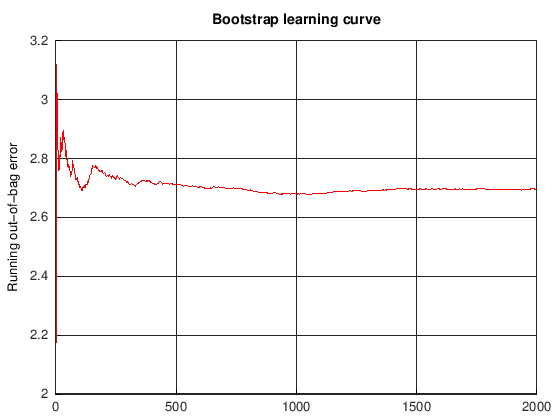

In [14]:
Y_hi  = Y(hi_idx, :);
n_hi  = n_pa(hi_idx);   s_hi  = s_pa(hi_idx);
ns_hi = ns_pa(hi_idx);  na_hi = na_pa(hi_idx);
ss_hi = ss_pa(hi_idx);

MAT_hi = bootlm (Y_hi(:,1), {n_hi, s_hi, ns_hi, na_hi, ss_hi}, ...
                 'continuous', [1:5], 'model', 'linear', 'display', 'off', ...
                 'nboot', 0, 'varnames', {'n','s','ns','na','ss'});

fprintf ('Running bootridge: Hi SES...\n')
tic
bootridge (Y_hi, MAT_hi.X, [], 1999, 0.05);
toc
ridge_hi = ans;

Running bootridge: full model (SES + PA + interactions)...
    bootridge at line 827 column 8

    bootridge at line 827 column 8

    bootridge at line 864 column 8


 Empirical Bayes Ridge Regression (.632 Bootstrap Tuning) - Summary
 *******************************************************************************

 Number of predictors (p): 63

 Number of outcomes (q): 3

 Sample size: 69

 Design effect (Deff): 1

 Bootstrap resamples (nboot): 1999

 Minimized .632 bootstrap prediction error: 2.95632

 Predicted R-squared: 0.015 (1.5%)

 Bootstrap optimized ridge tuning constant (lambda): 7.39966e+07

 Effective residual degrees of freedom (df_lambda): 69.0

 Residual variances (range): [207, 5.48e+03]

 Inferential degrees of freedom (df_t): 68.0
 Used for credible intervals and Bayes factors below.

 95% credible intervals for correlations between outcomes:
 (Prior on Fisher's z is flat/improper)

 Outcome J     Outcome I     correlation   CI_lower      CI_upper     
 1           

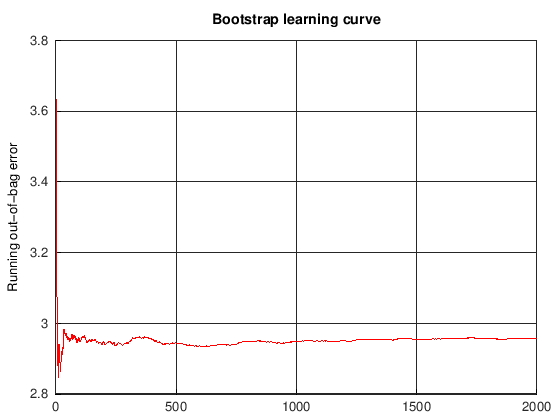

In [21]:
SES_bin = double (strcmp (SES, 'Hi'));

MAT_full = bootlm (Y(:,1), {SES_bin, n_pa, s_pa, ns_pa, na_pa, ss_pa}, ...
                   'continuous', [1:6], 'model', 'full', 'display', 'off', ...
                   'nboot', 0, 'varnames', {'SES','n','s','ns','na','ss'});

fprintf ('Running bootridge: full model (SES + PA + interactions)...\n')
tic
bootridge (Y, MAT_full.X, [], 1999, 0.05);
toc
ridge_full = ans;